<a href="https://colab.research.google.com/github/delta-vision0/DeepLearning/blob/main/RNN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Data Loaded!")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data Loaded!


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

def build_model(layer_type):
    model = Sequential()

    # Converts numbers → vectors
    model.add(Embedding(10000, 32, input_length=200))

    # Different models
    if layer_type == "RNN":
        model.add(SimpleRNN(32))
    elif layer_type == "LSTM":
        model.add(LSTM(32))
    elif layer_type == "GRU":
        model.add(GRU(32))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [4]:
models = ["RNN", "LSTM", "GRU"]
history_dict = {}

for m in models:
    print(f"\nTraining {m}...\n")

    model = build_model(m)

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_data=(x_test, y_test)
    )

    history_dict[m] = history


Training RNN...

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7414 - loss: 0.5175 - val_accuracy: 0.8061 - val_loss: 0.4294
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.7350 - loss: 0.5233 - val_accuracy: 0.7538 - val_loss: 0.5047
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.8842 - loss: 0.2810 - val_accuracy: 0.8433 - val_loss: 0.3918

Training LSTM...

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 111ms/step - accuracy: 0.7949 - loss: 0.4280 - val_accuracy: 0.8569 - val_loss: 0.3312
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - accuracy: 0.9036 - loss: 0.2462 - val_accuracy: 0.8677 - val_loss: 0.3075
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.9306 - loss: 0.1839 - val_accuracy: 0.8675 - val_loss: 0.3307

Training GRU...

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 147ms/step - accuracy: 0.7714 - loss: 0.4588 - val_accuracy: 0.8452 - val_loss: 0.3590
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 144ms/step - accuracy: 

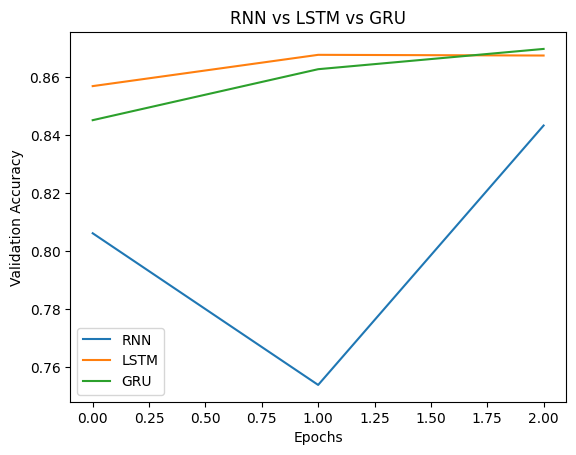

In [5]:
import matplotlib.pyplot as plt

for m in history_dict:
    plt.plot(history_dict[m].history['val_accuracy'], label=m)

plt.title("RNN vs LSTM vs GRU")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()